# Redshift DataSet Regressor: Linear Regression

In this notebook we will build a linear regression model using the redshift dataset.  Let's dive in! 

## import libraries

In [2]:
# arrays
import numpy as np

# unpacking files
import tarfile

# fits
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.table import Table
import pandas as pd

# plotting
from matplotlib import pyplot as plt

# sklearn 
from sklearn.model_selection import train_test_split #, RandomizedSearchCV, validation_curve
#from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Read and Inspect Data

First we will import our data and convert it into a pandas dataaframe

In [3]:
file_url = 'https://archive.stsci.edu/missions/hlsp/3d-hst/RELEASE_V4.0/Photometry/3dhst_master.phot.v4.1.tar'
tarfile.open(download_file(file_url, cache=True), "r:").extract('3dhst_master.phot.v4.1/3dhst_master.phot.v4.1.cat', '.')
tab = Table.read('3dhst_master.phot.v4.1/3dhst_master.phot.v4.1.cat', format='ascii').to_pandas()
tab.head()

,id,field,ra,dec,x,y,z_spec,z_peak,faper_F140W,eaper_F140W,...,flags,f140w_flag,star_flag,use_phot,near_star,nexp_f125w,nexp_f140w,nexp_f160w,lmass,Av
0,1.0,AEGIS,215.222382,53.004185,9590.5,3057.3,-1.0,0.0100,-82.0410,-82.041000,...,0,0,1,0,0,2,0,3,7.51,1.1
1,2.0,AEGIS,215.096588,52.918053,16473.2,3150.2,-1.0,0.0100,3.5078,0.074233,...,3,0,0,0,0,4,4,4,5.62,0.1
2,3.0,AEGIS,215.161469,52.959461,13060.1,2982.3,-1.0,0.2062,-1.9043,-1.904300,...,1,0,0,1,0,2,0,2,9.00,1.1
3,4.0,AEGIS,215.305298,53.052921,5422.8,2692.1,-1.0,0.0355,-72.3250,-72.325000,...,0,0,0,0,0,1,0,1,4.78,0.4
4,5.0,AEGIS,215.041840,52.871273,19894.6,2834.4,-1.0,0.3427,1890.5000,0.133300,...,0,1,2,0,1,0,3,0,11.57,0.5


Next, we can start to inspect our data.

In [4]:
tab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207967 entries, 0 to 207966
Data columns (total 38 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           207967 non-null  float64
 1   field        207967 non-null  object 
 2   ra           207967 non-null  float64
 3   dec          207967 non-null  float64
 4   x            207967 non-null  float64
 5   y            207967 non-null  float64
 6   z_spec       207967 non-null  float64
 7   z_peak       207967 non-null  float64
 8   faper_F140W  207967 non-null  float64
 9   eaper_F140W  207967 non-null  float64
 10  faper_F160W  207967 non-null  float64
 11  eaper_F160W  207967 non-null  float64
 12  f_F606W      207967 non-null  float64
 13  e_F606W      207967 non-null  float64
 14  f_F814W      207967 non-null  float64
 15  e_F814W      207967 non-null  float64
 16  f_F125W      207967 non-null  float64
 17  e_F125W      207967 non-null  float64
 18  f_F140W      207967 non-

## Clean up 

Before building and applying a regression model, we first need to inspect and clean the dataset. This process will explore the data we have, and filter out thing like missing data or data not relevant to our task.

To explore the physical parameters of the sample, we plot the spectroscopic redshift vs. the mass derived from the FAST phototmetric fit:

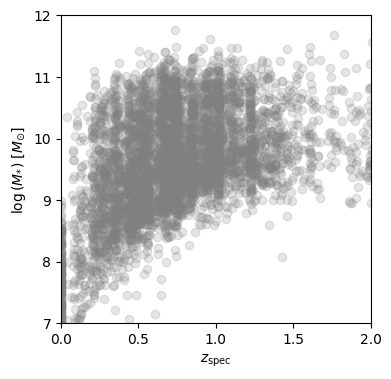

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(tab.z_spec, tab.lmass, alpha=0.2, color='grey')
ax.set_xlim(0, 2)
ax.set_ylim(7, 12)
ax.set_xlabel(r'$z_{\rm spec}$')
ax.set_ylabel(r'$\log{(M_{*})}\,\,[M_{\odot}]$')

plt.show()

By inspection of this plot, we will only keep sources with log(M)>9 to remove sources which do not have complete coverage across redshift.

In [6]:
print('number of datapoints originally = {}'.format(tab.shape[0]))
tab = tab[tab.lmass > 9].copy()
print('number of datapoints after drop = {}'.format(tab.shape[0]))

number of datapoints originally = 207967
number of datapoints after drop = 63390


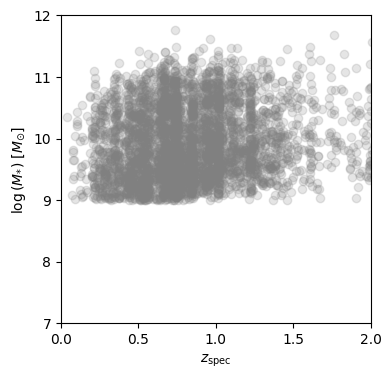

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(tab.z_spec, tab.lmass, alpha=0.2, color='grey')
ax.set_xlim(0, 2)
ax.set_ylim(7, 12)
ax.set_xlabel(r'$z_{\rm spec}$')
ax.set_ylabel(r'$\log{(M_{*})}\,\,[M_{\odot}]$')

plt.show()

## Define our target variable

We're interested in predicting redshift, so our "target" variable will be z_spec. The "features" will be all columns except for the spectroscopic and photometric redshifts.

In [8]:
target = 'z_spec'

Next, we will remove sources which have no constraints for our target variable:

In [9]:
print('number of datapoints originally = {}'.format(tab.shape[0]))
tab = tab[(tab[target] > 0)] 
print('number of datapoints after drop = {}'.format(tab.shape[0]))

number of datapoints originally = 63390
number of datapoints after drop = 4173


## Transform categorical data into a numerical representation
Categorical variables need to be modified to become numerical values. We can do this using pandas and sklearn have different tools to accomplish this.  We will use `pd.get_dummies` to perform one hot encoding - a technique used to convert categorical featurs into a binary matrix of 1s and 0s.  Below is a simple illustration of what this will do:

![](https://miro.medium.com/v2/resize:fit:1400/1*ggtP4a5YaRx6l09KQaYOnw.png)

Now let's apply this function to our data and inspect `tab`.

In [10]:
tab['field'].value_counts()

field
GOODS-N    1562
GOODS-S    1159
AEGIS       871
COSMOS      402
UDS         179
Name: count, dtype: int64

In [11]:
tab = pd.get_dummies(tab, columns=['field'],dtype=float)
tab

,id,ra,dec,x,y,z_spec,z_peak,faper_F140W,eaper_F140W,faper_F160W,...,nexp_f125w,nexp_f140w,nexp_f160w,lmass,Av,field_AEGIS,field_COSMOS,field_GOODS-N,field_GOODS-S,field_UDS
26,27.0,215.278076,53.036762,6798.20,2805.00,0.7405,0.6806,-71.0650,-71.06500,8.1873,...,2,0,2,9.23,1.1,1.0,0.0,0.0,0.0,0.0
69,70.0,215.244797,53.015137,8565.00,2871.10,1.1193,1.0916,-60.6090,-60.60900,3.2127,...,2,0,2,9.39,0.1,1.0,0.0,0.0,0.0,0.0
82,83.0,215.302460,53.055332,5379.80,2864.20,0.7383,0.7250,-40.9920,-40.99200,6.4949,...,2,0,2,9.55,0.5,1.0,0.0,0.0,0.0,0.0
144,145.0,215.281769,53.042686,6441.80,2935.60,0.7365,0.7842,-33.7210,-33.72100,2.2822,...,4,0,4,9.13,0.2,1.0,0.0,0.0,0.0,0.0
154,155.0,215.299683,53.055229,5449.70,2936.00,1.1371,1.1587,-54.5630,-54.56300,4.6583,...,2,0,2,9.68,0.7,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205837,41973.0,34.299271,-5.132092,18393.59,10474.45,0.6320,0.5790,-99.0000,-99.00000,30.6860,...,4,0,4,10.22,2.4,0.0,0.0,0.0,0.0,1.0
206257,42393.0,34.295635,-5.127980,18610.94,10721.14,0.8240,0.8001,-99.0000,-99.00000,58.5290,...,4,0,4,10.84,2.4,0.0,0.0,0.0,0.0,1.0
207042,43178.0,34.495361,-5.125964,6675.25,10842.28,0.2040,0.2097,-99.0000,-99.00000,41.6890,...,4,0,4,9.40,1.6,0.0,0.0,0.0,0.0,1.0
207646,43782.0,34.317093,-5.126375,17328.49,10817.60,2.3200,1.3523,-99.0000,-99.00000,13.4370,...,2,0,2,10.96,0.0,0.0,0.0,0.0,0.0,1.0


## Defining Features
Next, we will define the features. 

Let's drop a few of the features. The 'Av', 'lmass' and 'z_peak' values were all computed via FAST photometric fit, and so we will exclude them as well. In addition, we will exclude the categorical flag variables ('flags', 'f140w_flag', 'star_flag', 'use_phot', 'near_star' and 'field').

In [12]:
features = [col for col in tab.columns if (col != target)]
features = [col for col in features if (col != 'Av') and (col != 'lmass') and (col != 'z_peak') 
            and (col != 'flags') and (col != 'f140w_flag') and (col != 'star_flag') 
            and (col != 'use_phot') and (col != 'near_star') and (col != 'field') 
            and (col != 'field_UDS') and (col != 'ra') and (col != 'dec')]

In [13]:
features

['id',
 'x',
 'y',
 'faper_F140W',
 'eaper_F140W',
 'faper_F160W',
 'eaper_F160W',
 'f_F606W',
 'e_F606W',
 'f_F814W',
 'e_F814W',
 'f_F125W',
 'e_F125W',
 'f_F140W',
 'e_F140W',
 'f_F160W',
 'e_F160W',
 'tot_cor',
 'kron_radius',
 'a_image',
 'b_image',
 'flux_radius',
 'fwhm_image',
 'nexp_f125w',
 'nexp_f140w',
 'nexp_f160w',
 'field_AEGIS',
 'field_COSMOS',
 'field_GOODS-N',
 'field_GOODS-S']

## Check for and Imputing missing values 

In this particular dataset, we know via documentation that missing values of photometric errors are set to -99.  

Let's assume that we didn't have that info, What's some sanity checks we could do with our data to look for issues?  

In [14]:
# We shouldn't have negative errors -- check for negative values
tab[tab['e_F606W'] < 0].e_F606W.value_counts()

e_F606W
-99.0    118
Name: count, dtype: int64

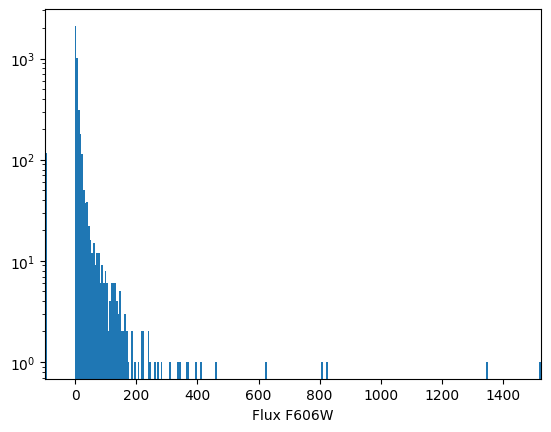

In [15]:
fig,ax=plt.subplots()
ax.hist(tab['f_F606W'],bins=300)
ax.set_yscale('log')
ax.set_xlabel('Flux F606W')
ax.set_xlim([tab['f_F606W'].min(),tab['f_F606W'].max()]);
#ax.set_xlim([tab['f_F606W'].min(),2000])

### Imputing missing values

There are several options for what to do with missing values in our datasets.  Here are a few options:

1. Impute missing values with mean, median, or another ML model like KNNs. 
2. I could drop that row from dataset 
3. Depending on the model I am using, I could leave as -99.  (This will not work with linear regression, but could work with ensemble methods we will cover later)

We will impute missing values of photometric errors (set to -99. in the table) by assigning them the median of the distribution.

In [16]:
# get columns associated with errors
errors = [col for col in features if ((col[:1] == 'e')or(col[:1] == 'f')) and (col[-1:] == 'W')]
errors

['faper_F140W',
 'eaper_F140W',
 'faper_F160W',
 'eaper_F160W',
 'f_F606W',
 'e_F606W',
 'f_F814W',
 'e_F814W',
 'f_F125W',
 'e_F125W',
 'f_F140W',
 'e_F140W',
 'f_F160W',
 'e_F160W']

In [17]:
# impute values with median
for error in errors:
    tab[error] = np.where(tab[error] < -90, tab[error].median(), tab[error])

Finally lets inspect distribution of features

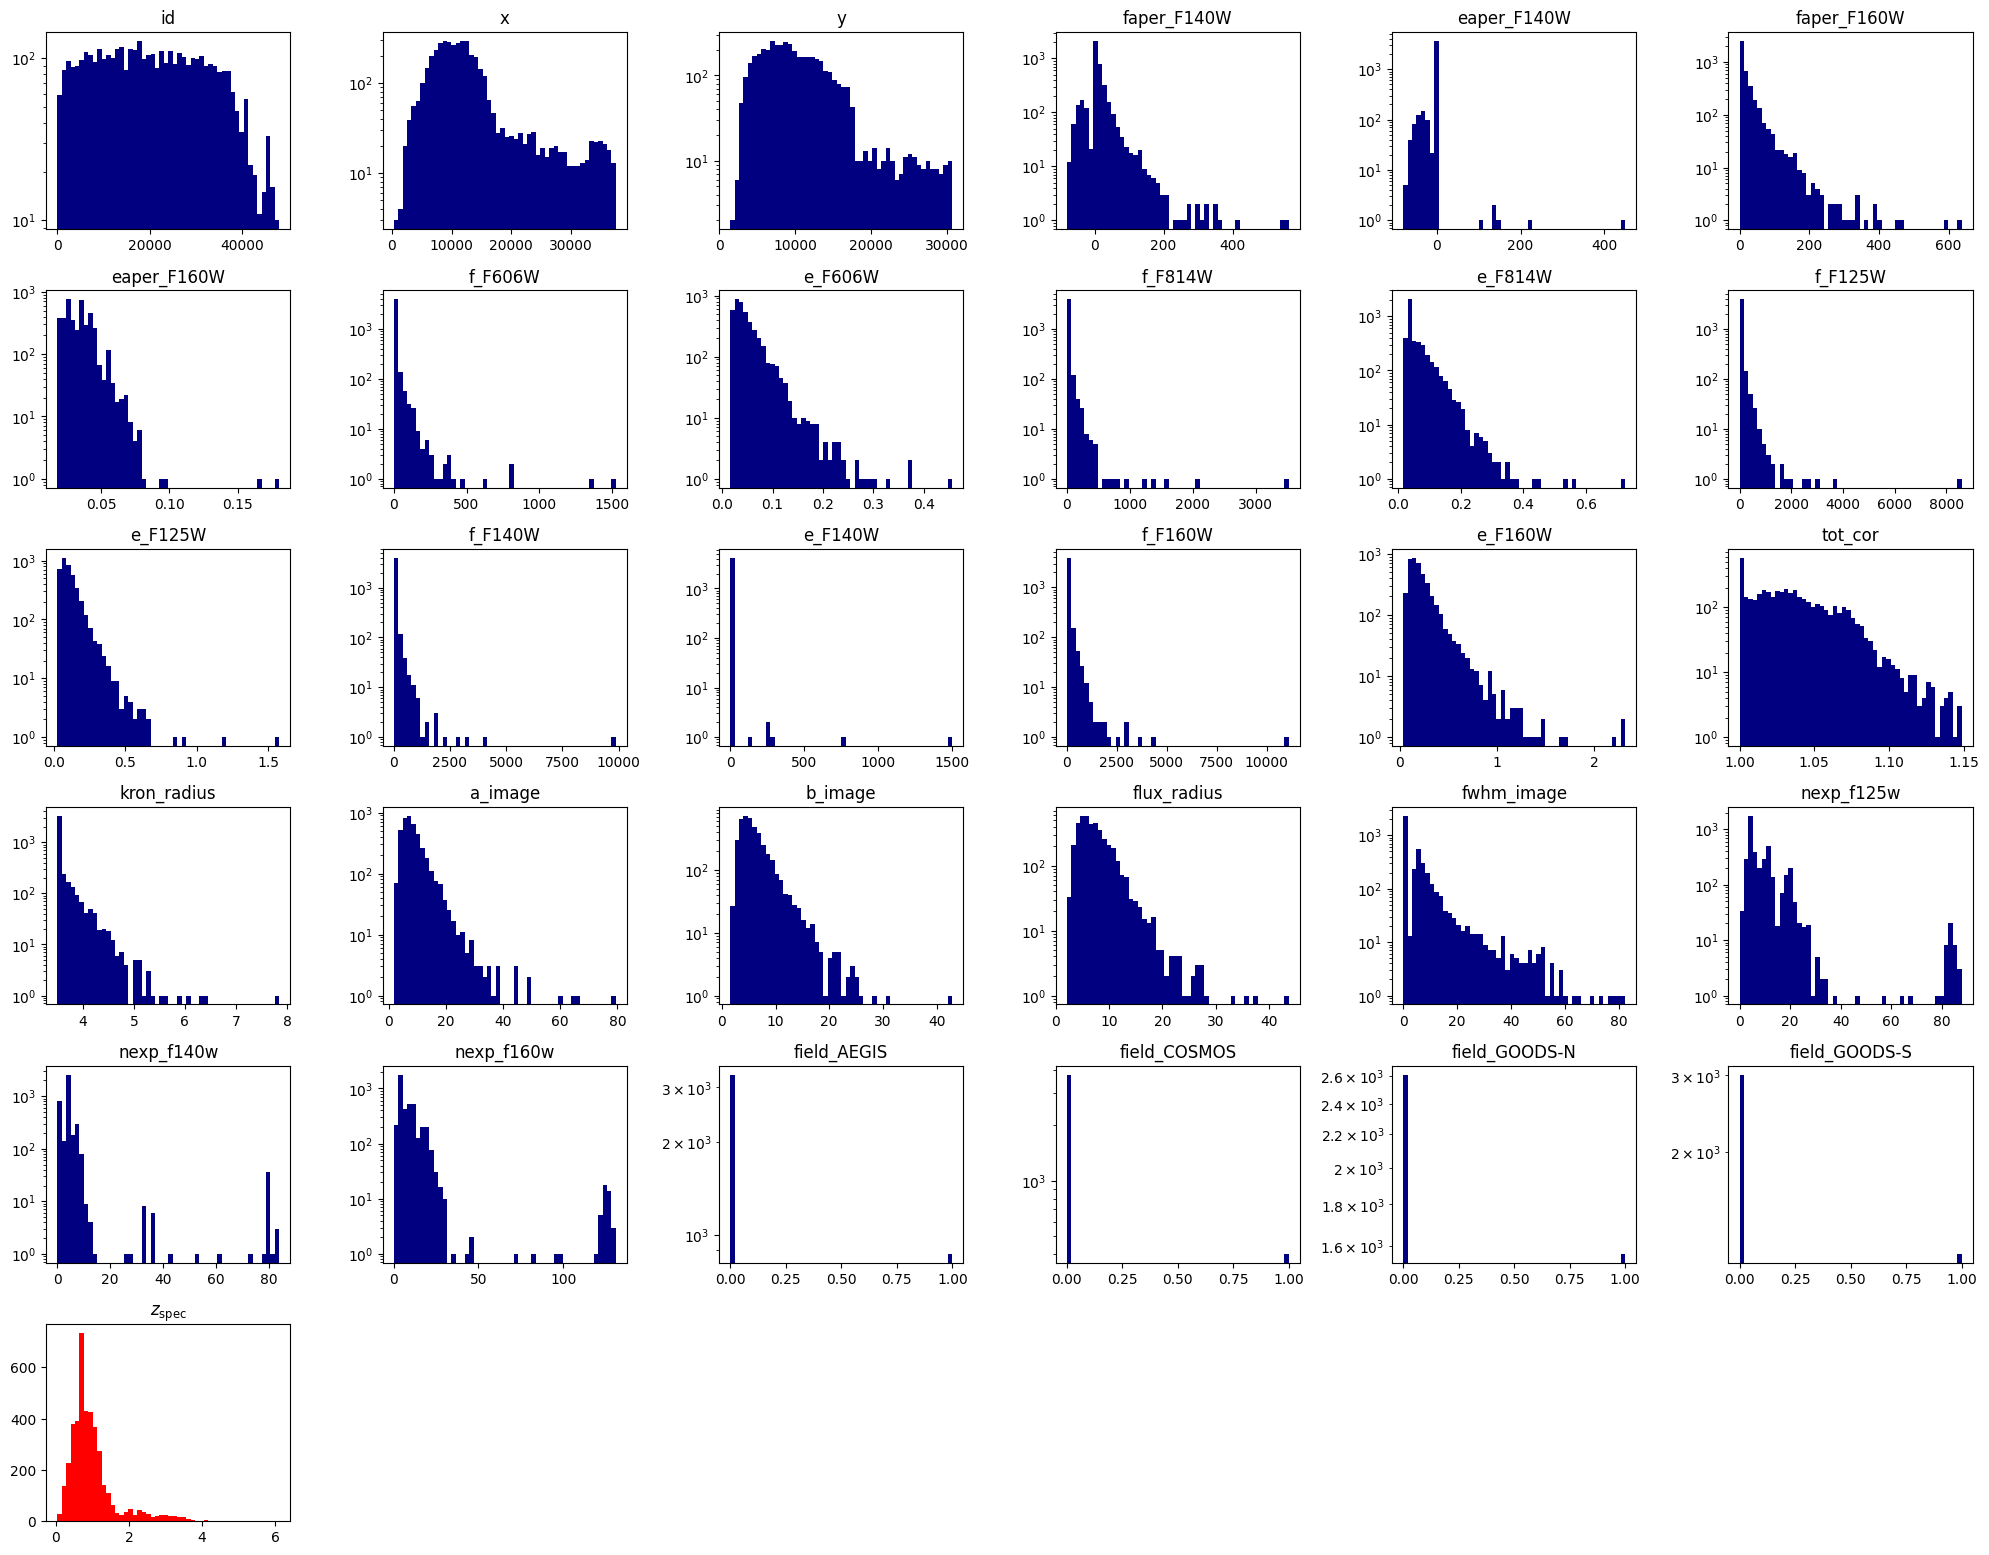

In [18]:
fig = plt.figure(0, [20, 18])

for k, feat in enumerate(features):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(tab[feat], bins=50, log=True, color='navy')
    ax.set_title(feat)

ax = fig.add_subplot(7, 6, len(features)+1)
ax.hist(tab[target], bins=50, color='red')
ax.set_title(r'$z_{\rm spec}$')

plt.tight_layout()
plt.show()

## Build and Evaluate Baseline Models 

When building machine learning models its good to start with a baseline model.  This will give you a place to reference back to in terms of the evaluation metrics you are computing. In this notebook, we will start with a few simple things just to get a feel of what performance we can expect from our models:

1. **Mean Regressor:** we predict our target is the mean of all the target values contained in our dataset
2. Multiple Linear regression with no feature engineering


### Test / Train Split 

Let's get started by splitting the data we have into three groups:

1. Training: Data used to train the model
2. Testing: Data used to evaluate models performance when performing model tuning
3. Validation: Data used to evaluate the models performance on unseen data points 

In [19]:
# Define X (features ) and y (target) for the dataset we are using
X = tab[features]
y = tab[target]

# first reserve 70% of the data for training, 30% for validation
X_train, X_validate, y_train, y_validate= train_test_split(X, y,  
                                                           test_size=0.3, 
                                                           random_state=42)

# second, split the validation set in half to obtain validation and test sets. 
X_validate, X_test, y_validate, y_test = train_test_split(X_validate, 
                                                          y_validate,  
                                                          test_size=0.5, 
                                                          random_state=42)

### Mean Regressor 

Next, lets build our mean regressor.  This can be done using sklearn's `DummyRegressor` class. 

In [20]:
from sklearn.dummy import DummyRegressor
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)

dummy_regr.predict(X_test)[0:10]

array([1.00031236, 1.00031236, 1.00031236, 1.00031236, 1.00031236,
       1.00031236, 1.00031236, 1.00031236, 1.00031236, 1.00031236])

In [21]:
# evaluate model 

# get predictions
y_predict = dummy_regr.predict(X_test) 
# compute mse with sklearns built in function
mse_dummy_regr= mean_squared_error(y_test, y_predict )
print('Mean squared error for mean regressor baseline: {}'.format(mse_dummy_regr))

Mean squared error for mean regressor baseline: 0.44378618168122164


Great! Now we have a metric that we really should beat from this point on.

## Naive Multiple Linear Regression with no feature engineering / inspection

Another thing we can do is just try multiple linear regression with our data.  I wouldn't expect good results here, but by comparing the results of this with the mean regressor will give us a sense for if there is signal in our data as the features currently are for linear regression.  

When building linear regression models, we have a choice of whether we standardize our data.  There are pros to either decision:

1. **Standardize data:** All of our features are on the same scale which means we can compare our learned coefficients.  This could give us insight into which of our features are the most helpful for making predictions.  However, we can interpret slopes 
2. **Do not standardize data:** We maintain the interpretation of coefficients.

I would like to use this initial pass to gain some instinct for what features are most important, so I will standardize our data and then compare the coefficients using `StandardScaler`.  `StandardScaler` transforms columns of your data to have mean 0 and standard deviation 1. 

In [22]:
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

linreg = LinearRegression().fit(X_train_scaled, y_train)

# evaluate model 
y_predict = linreg.predict(X_test_scaled) # get predictions
mse_mlr=mean_squared_error(y_test, y_predict )
print('Mean squared error for multiple linear regression baseline: {}'.format(mse_mlr))

Mean squared error for multiple linear regression baseline: 0.2684732411888965


Since we standardized our data we can compare the coefficients to see what feature is playing the biggest role in making predictions. Below I place the coefficients in to a dataframe.

In [23]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': linreg.coef_, 'importance':np.absolute(linreg.coef_)})
coef_df.sort_values(by='importance',ascending=False)

,Feature,Coefficient,importance
11,f_F125W,-0.906325,0.906325
15,f_F160W,0.589412,0.589412
17,tot_cor,0.392105,0.392105
13,f_F140W,0.323420,0.323420
3,faper_F140W,-0.265417,0.265417
4,eaper_F140W,0.197279,0.197279
18,kron_radius,0.156893,0.156893
26,field_AEGIS,-0.123672,0.123672
16,e_F160W,0.116780,0.116780
14,e_F140W,-0.099450,0.099450


Now, lets take the information above and see if we can use it to dive deeper into a few features

## Simple Linear Regression with Feature Engineering

Let's explore some of our top performing feature based on analysis above: f_F125W. First let's just see what the relationship looks like between feature and target.  

**Exercise**: Try uncommenting log scales and see what you discover.

Text(0, 0.5, 'z spec')

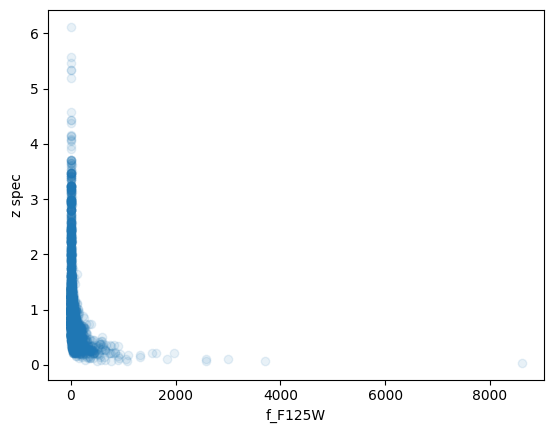

In [24]:
fig, ax = plt.subplots()
ax.scatter(tab.f_F125W,tab.z_spec,alpha=0.1)
ax.set_xlabel('f_F125W')
ax.set_ylabel('z spec')

################################
# Uncomment lines to see how plot changes 
################################
#ax.set_yscale('log')
#ax.set_xscale('log')

Based on data visualization above, lets engineer some new features and see what kind of performance that will give use.  In this example we will, take the log of both the feature and target.

Text(0, 0.5, 'log(z spec)')

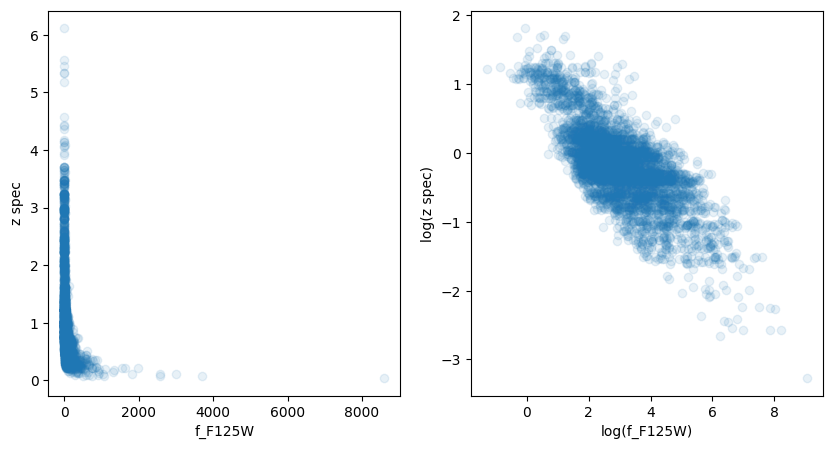

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].scatter(tab.f_F125W,tab.z_spec,alpha=0.1)
ax[1].scatter(np.log(tab.f_F125W),np.log(tab.z_spec),alpha=0.1)
ax[0].set_xlabel('f_F125W')
ax[0].set_ylabel('z spec')
ax[1].set_xlabel('log(f_F125W)')
ax[1].set_ylabel('log(z spec)')
#ax = scatter_matrix(tab[['f_F140W','f_F606W', 'z_spec']], ax=ax) #, diagonal='kde')

Now lets build a a few models with simple linear regression where we engineer our feature and target; in this example we take the log of both the feature and target


In [26]:
# Do Another test train split with only the f_F125W column
X_train, X_test, y_train, y_test = train_test_split(tab[['f_F125W']], 
                                                    tab.z_spec,
                                                    random_state = 0)

simplelinreg_log = LinearRegression().fit(np.log(X_train), np.log(y_train))

Next lets evaluate our model.  It is important to note that if we are predicting the log(z_spec) with our linear regression model, we will need to convert the models prediction back to z_spec by using `np.exp()`. 

In [27]:
# evaluate linreg_log model 
y_predict = np.exp(simplelinreg_log.predict(np.log(X_test))) # get note, we undo the log of the target by using np.exp
mse_linreg_log = mean_squared_error(y_test, y_predict )

# compare performance of our simple linear regression models with our baselines
print('Mean squared error for mean regressor baseline: {}'.format(mse_dummy_regr))
print('Mean squared error for multiple linear regression baseline: {}'.format(mse_mlr))
print('The MSE for linreg is {}'.format(mse_linreg_log))

Mean squared error for mean regressor baseline: 0.44378618168122164
Mean squared error for multiple linear regression baseline: 0.2684732411888965
The MSE for linreg is 0.2177704252322066


OK, nice! By using simple linear regression with engineering features, we now have a better score than our initial pass with MLR.  

Next, we will visualize our models prediction against the data below.

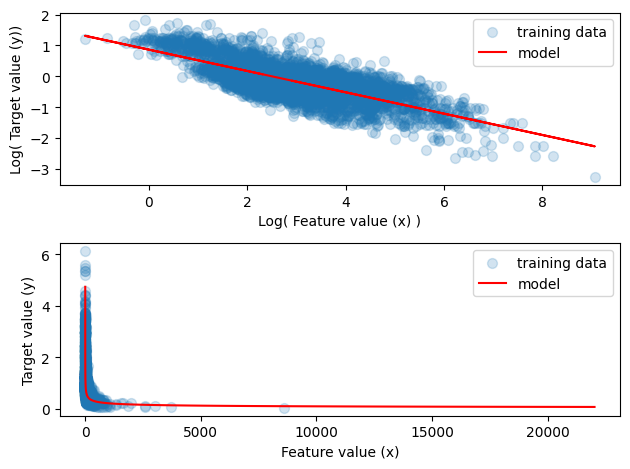

In [28]:
fig,ax = plt.subplots(2)

logx = np.log(tab[['f_F125W']])
logy= np.log(tab.z_spec)
ax[0].scatter(logx, logy, marker= 'o', s=50, alpha=0.2, label='training data')
ax[0].plot(logx, simplelinreg_log.coef_ * logx+ simplelinreg_log.intercept_, 'r-', label='model')
#ax[0].set_title('Least-squares linear regression')
ax[0].set_xlabel('Log( Feature value (x) )')
ax[0].set_ylabel('Log( Target value (y))')
ax[0].legend()

# values for drawing line
x = np.linspace(-2,10,100)
y_predictions = np.exp( simplelinreg_log.coef_ * x+ simplelinreg_log.intercept_ )

ax[1].scatter(tab.f_F125W, tab.z_spec, marker= 'o', s=50, alpha=0.2, label='training data')
ax[1].plot(np.exp(x), y_predictions, 'r-', label='model')
#ax[1].set_title('Least-squares linear regression')
ax[1].set_xlabel('Feature value (x)')
ax[1].set_ylabel('Target value (y)')
ax[1].legend()

fig.tight_layout()

## Try using MLR with a  adding a few more features and/ or using regularized regression 

First we will copy our dataframe for future feature engineering and pull out features based on the initial linear regression model we recreated earlier.

['faper_F140W', 'f_F125W', 'f_F140W', 'f_F160W', 'tot_cor']


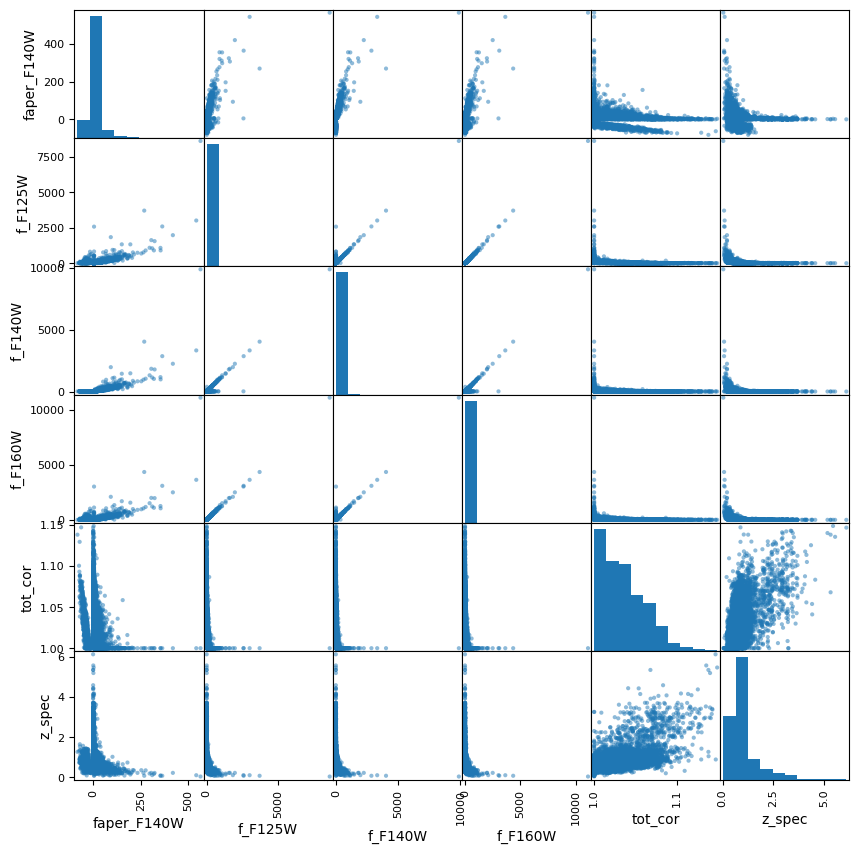

In [29]:
# copy dataframe 
tab_engineer = tab.copy()

# pull out feature list for coefficients of linear regression model; pick any coefficient larger than 0.1
new_features=coef_df[coef_df.importance > 0.2].Feature.to_list()
print(new_features)
pd.plotting.scatter_matrix(tab_engineer[new_features+[target]],figsize=(10,10));

One thing I want to highlight about above plot is that f_F160W and f_F125W are highly colinear. We want to avoid adding colinear features, and we know that f_F125W got us good performance earlier so we will drop f_F160W.  We will also incorporate the engineering we did for the SLR model earlier. 

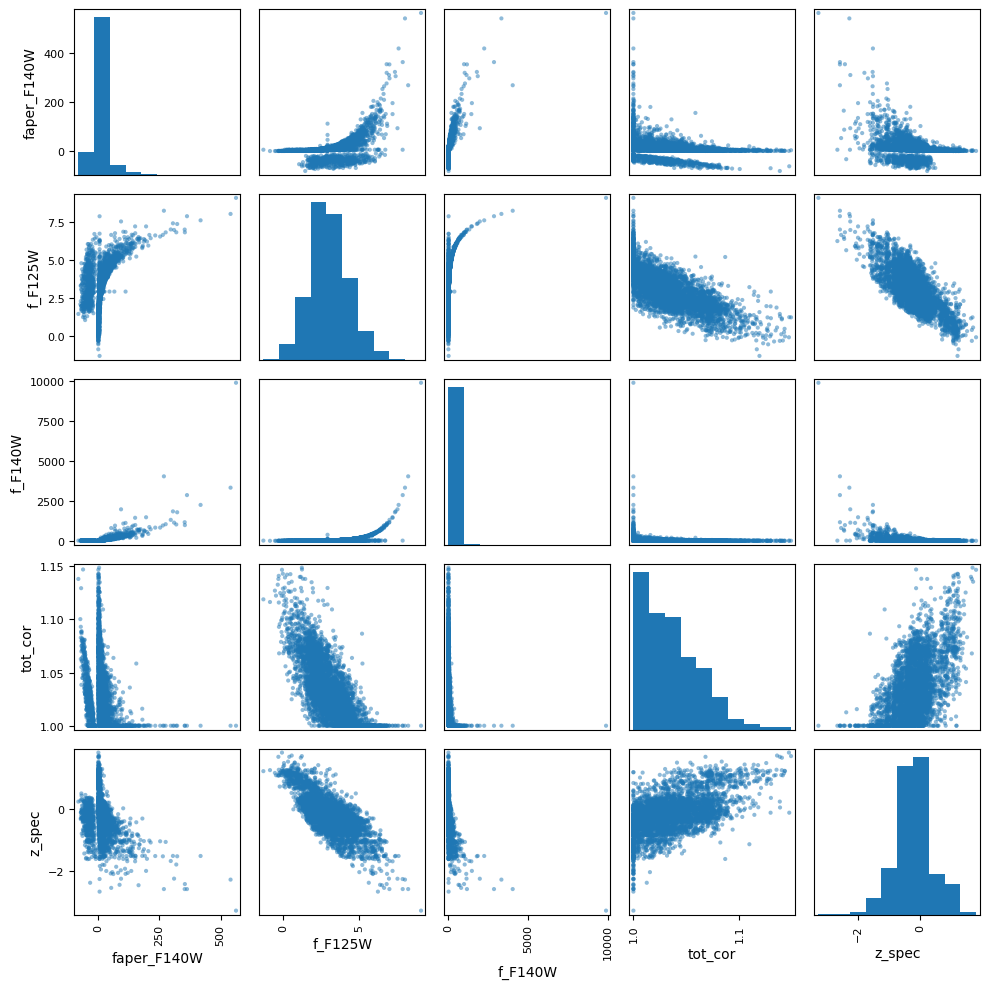

In [30]:
# remove f_160W because they are highly colinear
if 'f_F160W' in new_features:
    new_features.remove('f_F160W')

# engineer new features from simple linear regression example 
tab_engineer = tab.copy()
tab_engineer[target] = np.log(tab_engineer[target])
tab_engineer['f_F125W'] = np.log(tab_engineer['f_F125W'])

# plot new scatter matrix
pd.plotting.scatter_matrix(tab_engineer[new_features+[target]],figsize=(10,10))
plt.tight_layout();

Now lets use our new feature list and see if we get any performance improvement for our linear regression model with additional features.

In [31]:
X = tab_engineer[new_features]
y = tab_engineer[target]

# first reserve 70% of the data for training, 30% for validation
X_train, X_validate, y_train, y_validate= train_test_split(X, y,test_size=0.3, random_state=42)

# second, split the validation set in half to obtain validation and test sets. 
X_validate, X_test, y_validate, y_test = train_test_split(X_validate, y_validate, test_size=0.5, random_state=42)

# Scale data so we can compare slopes 
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

linreg_eng = LinearRegression().fit(X_train_scaled, y_train)

# evaluate model 
y_predict = np.exp(linreg_eng.predict(X_test_scaled))# get predictions
mse_mlr_eng=mean_squared_error(np.exp(y_test), y_predict )
print('Mean squared error for multiple linear regression baseline plus 1 engineerged feature and target: {}'.format(mse_mlr_eng))

Mean squared error for multiple linear regression baseline plus 1 engineerged feature and target: 0.20720197234796361


In [32]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': linreg_eng.coef_, 'importance':np.absolute(linreg_eng.coef_)})
coef_df.sort_values(by='importance',ascending=False)

,Feature,Coefficient,importance
1,f_F125W,-0.447300,0.447300
2,f_F140W,-0.057962,0.057962
0,faper_F140W,0.054893,0.054893
3,tot_cor,0.013146,0.013146


## OPTIONAL: Explore Regularization

Finally, let's see if we use some regularization techniques if that improves performance of our model.  When using a regularization technique it is important to explore the hyper paramter $\alpha$.  In the code below we will build several models for both Ridge and Lasso regresion using different values of $\alpha$.

In [33]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn import preprocessing

alphas = np.logspace(-7, 7, 11)
models_lasso={}
models_ridge={}
for alpha in alphas:
    # build model
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_train_scaled, y_train)
    models_lasso[alpha]=model

    # build model
    modelr = Ridge(alpha=alpha, max_iter=1000000)
    modelr.fit(X_train_scaled, y_train)
    models_ridge[alpha]=modelr

Next, we will evaluate these models with our testing data and plot how our performance changes with $\alpha$.

In [34]:
# function to evaluate models 
def evaluate(model,X_test_scaled,y_test):
    y_predict = np.exp(model.predict(X_test_scaled)) # get predictions and undo log of target
    return mean_squared_error(np.exp(y_test), y_predict ) # compute MSE

# compute MSE for all values of alpha
mse_array_lasso = [evaluate(model,X_test_scaled,y_test) for model in models_lasso.values()]
mse_array_ridge = [evaluate(model,X_test_scaled,y_test) for model in models_ridge.values()]

Best score from Ridge Regression 0.2072019723534363
Best score from Lasso Regression 0.2072020325482145


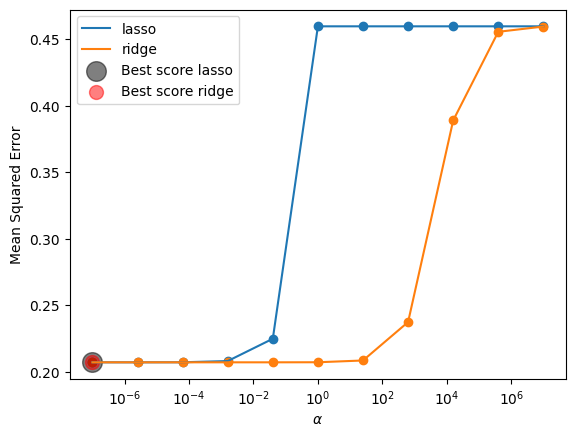

In [35]:
# plot results and print performance of best model
fig,ax=plt.subplots()
ax.plot(alphas,mse_array_lasso,label='lasso')
ax.scatter(alphas,mse_array_lasso)

ax.plot(alphas,mse_array_ridge,label='ridge')
ax.scatter(alphas,mse_array_ridge)

ax.scatter(alphas[np.argmin(mse_array_lasso)],np.array(mse_array_lasso).min(), c='k', s=200,alpha=0.5,label='Best score lasso')
ax.scatter(alphas[np.argmin(mse_array_ridge)],np.array(mse_array_ridge).min(), c='r', s=100,alpha=0.5,label='Best score ridge')

ax.legend()
ax.set_xscale('log')
ax.set_ylabel('Mean Squared Error')
ax.set_xlabel("$\\alpha$")

print("Best score from Ridge Regression {}".format(mse_array_ridge[np.argmin(mse_array_ridge)]))
print("Best score from Lasso Regression {}".format(mse_array_lasso[np.argmin(mse_array_lasso)]))

Something interesting we can do with regularization is see how are linear regression coefficients change with alpha. Below we plot this for both Ridge and Lasso regression. 

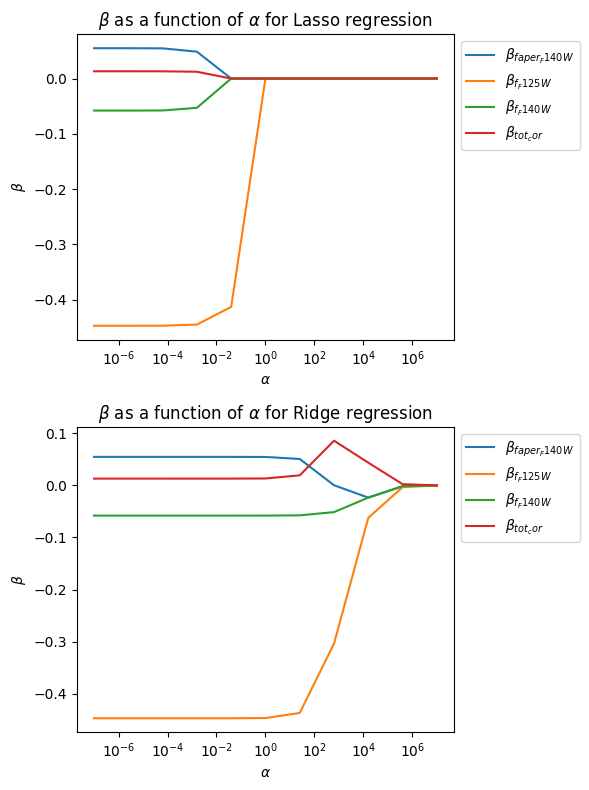

In [36]:
def plot_alpha_v_coef(ax, alphas, coefs, column_names, method='Lasso'):
    '''
    plots alpha versus the beta coefficients 
    '''
    for feature in range(len(coefs[0])):
            ax.plot(alphas, coefs[:, feature],
                     label="$\\beta_{{{}}}$".format(column_names[feature]))  #'{} order'.format(feature+1))
    ax.set_xscale('log')
    ax.set_title("$\\beta$ as a function of $\\alpha$ for {} regression".format(method))
    ax.set_xlabel("$\\alpha$")
    ax.set_ylabel("$\\beta$")
    ax.legend(loc="upper left",bbox_to_anchor=(1,1))

# get coef matrix
coefs_lasso = np.zeros((len(alphas), len(X.columns)))
for i,model in enumerate(models_lasso.values()):
    coefs_lasso[i] = model.coef_
coefs_ridge = np.zeros((len(alphas), len(X.columns)))
for i,model in enumerate(models_ridge.values()):
    coefs_ridge[i] = model.coef_

fig,ax=plt.subplots(2,figsize=(6,8))
plot_alpha_v_coef(ax[0], alphas, coefs_lasso, X.columns, method='Lasso')
plot_alpha_v_coef(ax[1], alphas, coefs_ridge, X.columns, method='Ridge')
fig.tight_layout()

## Print Performance of All Models 

In [37]:
print('Mean squared error for mean regressor baseline: {}'.format(mse_dummy_regr))
print('Mean squared error for multiple linear regression baseline: {}'.format(mse_mlr))
print('The MSE for linreg is {}'.format(mse_linreg_log))
print('Mean squared error for multiple linear regression baseline plus 1 engineerged feature and target: {}'.format(mse_mlr_eng))
print("Best score from Ridge Regression {}".format(mse_array_ridge[np.argmin(mse_array_ridge)]))

Mean squared error for mean regressor baseline: 0.44378618168122164
Mean squared error for multiple linear regression baseline: 0.2684732411888965
The MSE for linreg is 0.2177704252322066
Mean squared error for multiple linear regression baseline plus 1 engineerged feature and target: 0.20720197234796361
Best score from Ridge Regression 0.2072019723534363


In [38]:
# compare error to z_peak and see how far we have to go 
print("Best score from Astronomy Paper {}".format(mean_squared_error(tab.loc[X_test.index].z_spec,tab.loc[X_test.index].z_peak)))

Best score from Astronomy Paper 0.08327214985623003


## Exercise:

Can you do better than what we have done so far by engineering new features? 
